# DQN on CartPole-v1 with Stable Baselines 3

This notebook implements the Cart-Pole example (DQN, discrete actions) using Stable Baselines 3. For a Matlab implementation you can see also [here](https://se.mathworks.com/help/reinforcement-learning/ug/design-dqn-using-rl-designer.html).

**Note**: the _cartpole_ is part of the gymnasium (formerly gym) examples. stable_baselines3 only works with gymnasium for versions equal or newer than 2.0.0 due to changes in the ```step``` function. 


## 1. Setup & Dependencies

In [15]:
# %%
#!pip install stable-baselines3[extra] matplotlib
import os
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.results_plotter import load_results, ts2xy, X_TIMESTEPS
import matplotlib.pyplot as plt
import numpy as np

# visualisation in Jupyter
from matplotlib import animation
from IPython.display import HTML

## 2. Import & Inspect the CartPole Environment

In [16]:
env = gym.make("CartPole-v1", render_mode="rgb_array", max_episode_steps=500) # Discrete(2) actions, Box(4,) observations  [oai_citation:1‡gymlibrary.dev](https://www.gymlibrary.dev/environments/classic_control/cart_pole/?utm_source=chatgpt.com)
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)
env_Monitor = Monitor(env, filename=os.path.join(log_dir, "monitor.csv"))             # Record episode rewards
# the observation space shows the maximum/minimum allowed values for each of the 4 observation 
# variables (cart position, cart velocity, pole angle, pole velocity at tip)
print("Observation space:", env.observation_space) 
# the action space shows the number of discrete actions available (0 or 1, push cart left or right). 
# it is translated in the environment to a force of +/- F_max applied to the cart.
print("Action space     :", env.action_space)

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space     : Discrete(2)


## 3. Create a DQN Agent

The parameters set for the agent and learning: 
- **Policy:** MLP with two hidden layers of 128 units (instead of default 256) - see net_arch  
- **Learning rate:** 2e-4
- **Replay buffer:** 50 000: how many samples are saved in the buffer for learning, each consisting from action, state, next state, reward, and done flag. 
- **Batch size:** 32 sampled from replay buffer
- **poliak update factor $\tau$**: 1.0 corresponds to a hard update of the target Q-network
- **γ (discount):** 0.99: describes how future rewards are weighted relative to each other over time
- **exploration_fraction**: fraction of training over which exploration is reduced
- **exploration final eps**: final value of $\epsilon$ for exploration (starting from 1.0)
- **learning starts**: Use first 10 000 steps to fill up replay buffer and ensure diversity in experience
- **training frequency**: Q-network is updated every 4 steps. 
- **target update interval**: every 1000 steps the target network is overwritten with the (learned) Q-network


In [17]:
model = DQN(
    policy="MlpPolicy",
    env=env_Monitor,
    learning_rate=2e-4,
    buffer_size=50_000,
    batch_size=32,
    tau=1.0, 
    gamma=0.99, 
    exploration_fraction=0.3, 
    exploration_final_eps=0.01,  
    learning_starts=10_000,
    train_freq=4, # model update every 4 steps
    target_update_interval=1_000, # how often the target network is updated
    verbose=0, # set to 1 to activate periodic stats tables
    policy_kwargs=dict(net_arch=[128, 128]),    # two hidden layers with 128 units each
)

## 4. Train with Evaluation Callback

We train up to 75 000 steps, evaluating every 5 000 steps and saving the best model. When evaluating, the current best policy is applied without exploration (i.e., actions are chosen deterministically)

In [18]:
eval_callback = EvalCallback(
    env,
    #best_model_save_path="./logs/",
    #log_path="./logs/",
    eval_freq=5_000,
    n_eval_episodes=5,
    deterministic=True,
    verbose=0,
)

model.learn(total_timesteps=75_000, callback=eval_callback, progress_bar=True)

Output()

c:\Users\cane76ca\AppData\Local\anaconda3\envs\py311\Lib\site-packages\stable_baselines3\common\evaluation.py:71: 
UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting 
modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first
with ``Monitor`` wrapper.
  warnings.warn(

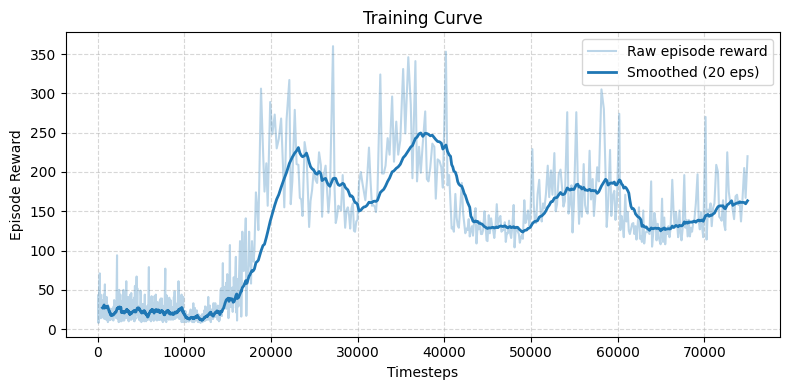

In [19]:

# 1) Where your Monitor wrote monitor.csv files:
log_dir = "./logs/"

# 2) Load & concatenate all Monitor logs under that folder:
data = load_results(log_dir)    # → pandas DataFrame

# 3) Extract (timesteps, episode_reward)
x, y = ts2xy(data, X_TIMESTEPS)

# 4) Smooth with a moving‐average window over N episodes:
window = 20
kernel = np.ones(window) / window
y_smooth = np.convolve(y, kernel, mode="valid")
x_smooth = x[window-1:]

# 5) Plot both raw and smoothed curves:
plt.figure(figsize=(8,4))
plt.plot(x,      y,        color="C0", alpha=0.3, label="Raw episode reward")
plt.plot(x_smooth, y_smooth, color="C0", linewidth=2, label=f"Smoothed ({window} eps)")
plt.xlabel("Timesteps")
plt.ylabel("Episode Reward")
plt.title("Training Curve")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

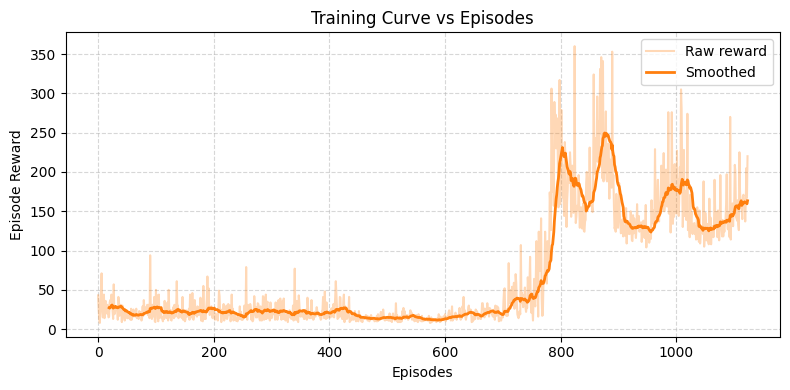

In [20]:
from stable_baselines3.common.results_plotter import X_EPISODES

xe, ye = ts2xy(data, X_EPISODES)
ys      = np.convolve(ye, kernel, mode="valid")
xe_s    = xe[window-1:]

plt.figure(figsize=(8,4))
plt.plot(xe,      ye,    color="C1", alpha=0.3, label="Raw reward")
plt.plot(xe_s,    ys,    color="C1", linewidth=2, label="Smoothed")
plt.xlabel("Episodes")
plt.ylabel("Episode Reward")
plt.title("Training Curve vs Episodes")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
# note: initial episodes are very short; thus 

## 5. Evaluate & Simulate

### 5.1 Quantitative Evaluation

Compute mean±std reward over 10 episodes:

In [21]:
mean_reward, std_reward = evaluate_policy(model, env_Monitor, n_eval_episodes=10)
print(f"Mean reward: {mean_reward:.2f} ± {std_reward:.2f}")

Mean reward: 187.50 ± 49.16


### 5.2 Visual Simulation

Run and render a few episodes:

In [ ]:
for ep in range(3):
    obs, info = env.reset()
    done = False
    total_r = 0.0
    iSteps = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        # terminated: episode ended because observation space was violated (here: task failed)
        # truncated: episode ended because max_episode_steps was reached
        total_r += reward
        iSteps += 1
    print(f"Episode {ep+1} cummulated reward: {total_r:.0f} over {iSteps} steps")
env.close()

Episode 1 cummulated reward: 155 over 155 steps
Episode 2 cummulated reward: 175 over 175 steps
Episode 3 cummulated reward: 146 over 146 steps


In [23]:
def simulate_and_capture(model, env, max_steps=200):
    obs, _ = env.reset()
    frames = []
    for _ in range(max_steps):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)
        frames.append(env.render())
        if done or truncated:
            break
    return frames

def create_animation(myAgent, env): 
    frames = simulate_and_capture(myAgent, env)
    fig = plt.figure(figsize=(4,4))
    plt.axis('off')
    im = plt.imshow(frames[0])

    def update(i):
        im.set_data(frames[i])
        return (im,)

    myAnimation = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=50, blit=True
    )
    plt.close(fig)               
    return myAnimation
    
# assume `model` and `env` are already defined
frames = simulate_and_capture(model, env)
anim = create_animation(model, env)

In [24]:
# embed the animation in the notebook
HTML(anim.to_jshtml())

## 6. Save & Load the Trained Agent

In [25]:
model.save("dqn_cartpole_sb3")
print('saved model')


saved model


In [26]:
# model = DQN.load("dqn_cartpole_sb3", env=env)
model = DQN.load("agent_dqn_cartpole_rewardsimple", env=env)


Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


### Task 1 (15 min)
Load the model and run it for 500 steps. You do not need to train it again, but can use the _agent_dqn_cartpole_rewardsimple_.  
Record the position and plot it using e.g. plt.plot().  
The observation space is:  
| Num | Observation           | Min                 | Max               |
| --- | --------------------- | ------------------- | ----------------- |
| 0   | Cart Position         | -4.8                | 4.8               |
| 1   | Cart Velocity         | -Inf                | Inf               |
| 2   | Pole Angle            | ~ -0.418 rad (-24°) | ~ 0.418 rad (24°) |
| 3   | Pole Angular Velocity | -Inf                | Inf               |

The action is discrete (0 or 1), which gets translated into $\pm 10 N$ of force onto the cart. 
<!-- code: 
env =  gym.make(\"CartPole-v1\", render_mode=\"rgb_array\")
model = DQN.load(\"agent_dqn_cartpole_rewardsimple\", env=env)
N = 500
observations = []
obs, info = env.reset()
done = False
total_r = 0.0
for i in range(N): 
    action, _ = model.predict(obs, deterministic=True)
    observations += [obs]
    obs, reward, done, truncated, info = env.step(action)
    frames.append(env.render())
    if done or truncated:
        break
observations = np.array(observations)
plt.plot(observations[:,0])

frames = simulate_and_capture(model, env)
anim = make_animation(frames)
HTML(anim.to_jshtml())
-->
* What do you notice?
<!-- 
* Due to the discrete force, discontinuous acceleration occurs, which can be seen in the position
* There might be a drift in the position, depending on the run
-->
* How could this be improved?
<!-- 
* Other RL algorithms (e.g., PPO, SAC) allow for continuous actions
* Designing the reward to punish drift and velocities can eliminate drift
--> 

In [27]:
# add code here


### Task 2 (5 min) 
Have a look at the training curve.
* What happens in the first 10 000 steps? Why is there no progress?
<!-- parameter learning_starts is 10 000; before learning, the replay buffer is filled (partially) to ensure a sufficiently diverse batch of experience --> 
* What information does the episode length tell us in the training process?
<!-- 
* The environment terminates when the allowed observation range for angle/position is left
* Thus, the episodes are initially very short as the system completely fails to balance 
-->